# 🔍 Notebook 07 — Explainability (SHAP)

**Objective**: Generate global and local explanations for the Fraud Risk Model using SHAP values.

In [1]:
import pandas as pd
import shap
import joblib
import os
import matplotlib.pyplot as plt

FEATURE_DIR = os.path.join('..', 'data', 'features')
MODEL_DIR = os.path.join('..', 'outputs', 'models')
OUTPUT_DIR = os.path.join('..', 'outputs')

txn = pd.read_parquet(os.path.join(FEATURE_DIR, 'transactions_selected.parquet'))
clf = joblib.load(os.path.join(MODEL_DIR, 'lgbm_is_aml.pkl'))

drop_cols = ['transaction_id', 'customer_cif_id', 'customer_account_number', 'device_id_fingerprint', 'wallet_account_id', 'is_aml', 'aml_typology', 'fraud_intensity_score', 'fis_band']
features = [c for c in txn.columns if c not in drop_cols]
X = txn[features].sample(n=5000, random_state=42) # Sample for SHAP computation

# Calculate SHAP values
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X)

print("SHAP values calculated.")

/opt/homebrew/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values calculated.


/opt/homebrew/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


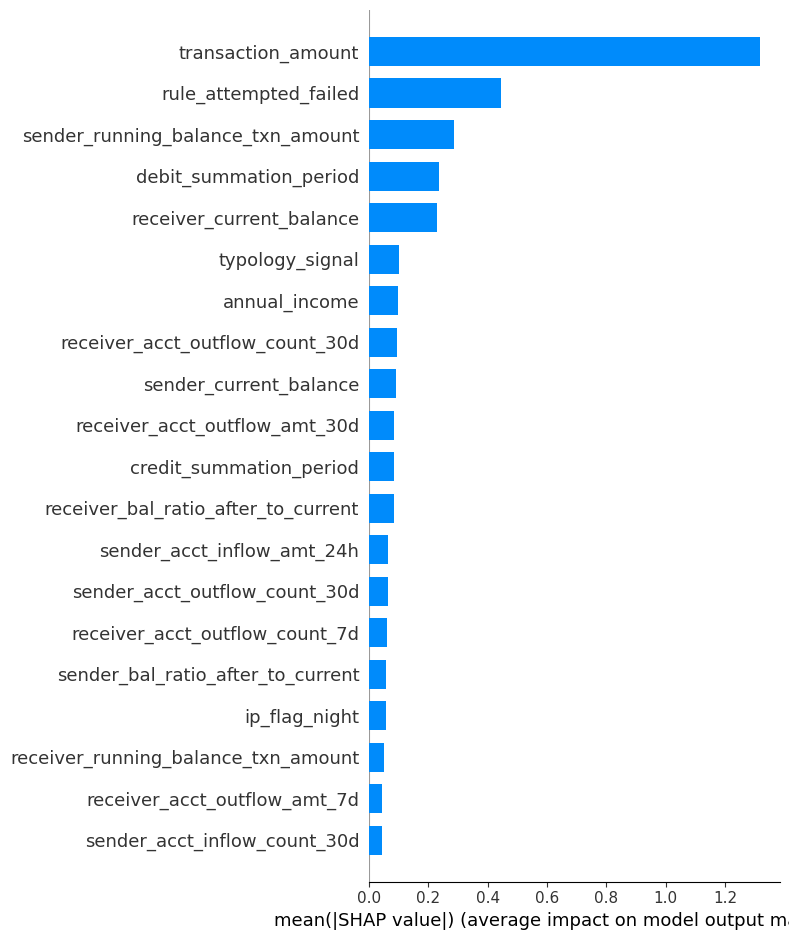

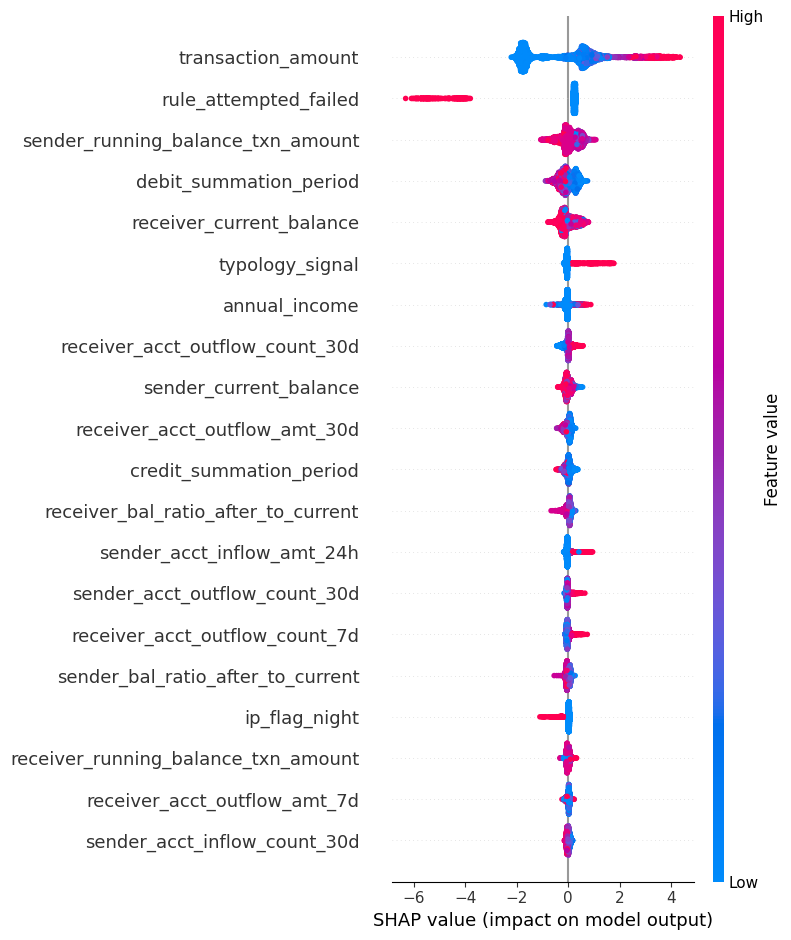

In [2]:
# Global Explainability: SHAP Summary Plot
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reports', 'shap_summary_bar.png'))
plt.show()

# SHAP Feature Impact
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reports', 'shap_summary_impact.png'))
plt.show()